# Seasonal maps

Annualization composes with everything else, so a seasonal map is one chain — see
[Annualization and seasonalization](core-annualization.ipynb) for the DJF-wraparound
mechanics behind `months=[-12, 1, 2]`.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
da = ds.x.da

jja = da.x.annualize(months=[6, 7, 8])
# DJF: December belongs to the *previous* calendar year
djf = da.x.annualize(months=[-12, 1, 2])

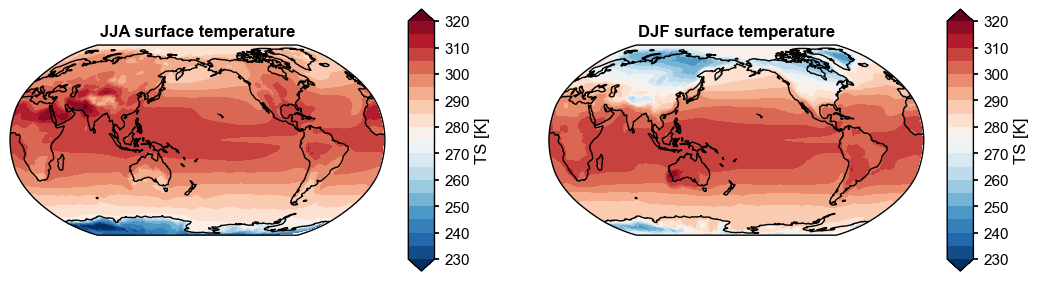

In [3]:
ax_loc = {'a': (0, 0), 'b': (0, 1)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(13, 3.4), wspace=0.15)

levels = np.linspace(230, 320, 19)
jja.mean('time').x.plot(ax=axd['a'], title='JJA surface temperature', levels=levels)
djf.mean('time').x.plot(ax=axd['b'], title='DJF surface temperature', levels=levels)
x4c.showfig(fig)